учитвыая задачу мы не хотим домножать на конастану скейлер после N успешных прогонов тк мы хотим максиманльо оптимальные результаты

Поэтому хочется прогнать градиенты без amd и посмотреть на статистики, так как scaler и так может смотреть на градиенты, то статистику можно посмотреть через него

In [1]:
#!bash download_data.sh

In [2]:
from train import *
import matplotlib.pyplot as plt
scaler_test = LossScaler()

stats = dict(zip(["max", "min"], [[],[]]))

def plot_stats(optimizer):
    max_grad = -float('inf')
    min_grad = float('inf')
    for group in optimizer.param_groups:
        for p in group['params']:
            if p.grad is not None:
                grad = p.grad.data
                max_grad = max(max_grad, grad.max().item())
                min_grad = min(min_grad, grad.min().item())

    stats['max'].append(max_grad)
    stats['min'].append(min_grad)
    optimizer.step()

scaler_test.step = plot_stats

Loss: 0.6699 Accuracy: 89.3996: 100%|██████████| 40/40 [01:16<00:00,  1.91s/it]


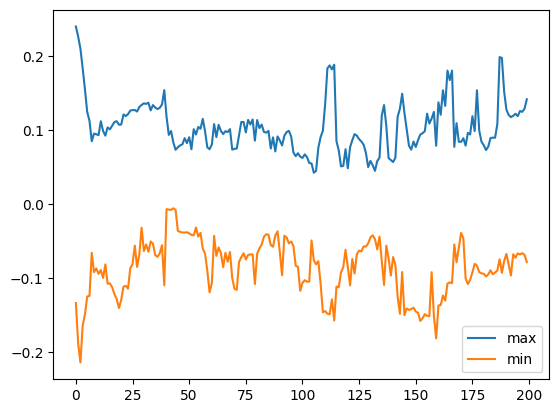

In [3]:
train(scaler_test)

plt.plot(stats['max'], label='max')
plt.plot(stats['min'], label='min')
plt.legend()
plt.show()

In [6]:
# В случае статики можно взять интервал [-a, a] в котором точно будут лежать градиенты и обозначить
# scaling factor = max_value / a
scaler_static = LossScaler(scaler_type="static", interval = 0.3)
train(scaler_static)

Loss: 0.5857 Accuracy: 98.9025: 100%|██████████| 40/40 [01:20<00:00,  2.02s/it]


In [ ]:
# для динамики по стандарту по чуть чуть величиываем барьер в случае успешных прогонов window раз подряд
scaler_dynamic = LossScaler(scaler_type="dynamic", interval = 0.3)
train(scaler_dynamic)

Loss: 0.5939 Accuracy: 98.1466:  78%|███████▊  | 31/40 [01:02<00:13,  1.53s/it]

Inf in grad!


Loss: 0.5863 Accuracy: 98.5235:  62%|██████▎   | 25/40 [00:54<00:45,  3.03s/it]

Inf in grad!


Loss: 0.5875 Accuracy: 98.484:  65%|██████▌   | 26/40 [00:54<00:31,  2.25s/it] 

...

Loss: 0.5863 Accuracy: 98.7135:  57%|█████▊    | 23/40 [00:47<00:26,  1.54s/it]

Inf in grad!


Loss: 0.5856 Accuracy: 98.7592:  80%|████████  | 32/40 [01:02<00:09,  1.21s/it]

Inf in grad!


Loss: 0.5838 Accuracy: 98.697: 100%|██████████| 40/40 [01:16<00:00,  1.92s/it] 
